# Machine Learning 1 - Practica: Regularizacion, Grid Search y SVM

## Prediccion de Aprobacion - Calculo 1

**Profesor:** Diego Stalder  
**Fecha:** 12 de Agosto de 2026

---

### Objetivos de la Practica

1. **Regularizacion**: Implementar Ridge (L2), Lasso (L1) y Elastic Net
2. **Grid Search**: Optimizar hiperparametros con validacion cruzada
3. **SVM**: Implementar SVM lineal, RBF y optimizar con Grid Search
4. **Comparacion**: Evaluar y comparar todos los modelos
5. **Visualizacion**: Visualizar fronteras de decision y vectores soporte

---

In [1]:
# =============================================================================
# IMPORTS Y CONFIGURACION
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVC, SVR
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, mean_squared_error,
                             precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("="*80)
print("PRACTICA: REGULARIZACION, GRID SEARCH Y SVM")
print("Prediccion de Aprobacion - Calculo 1")
print("="*80)

PRACTICA: REGULARIZACION, GRID SEARCH Y SVM
Prediccion de Aprobacion - Calculo 1


## 1. Carga y Preparacion de Datos

In [2]:
# =============================================================================
# 1. CARGA DE DATOS
# =============================================================================
print("\nCargando datos...")

# Intentar cargar datos reales
try:
    df = pd.read_csv("datos_concatenados.csv")
    print(f"Datos cargados: {len(df):,} registros")
except FileNotFoundError:
    print("No se encontro el archivo 'datos_concatenados.csv'")
    print("Generando datos sinteticos para demostracion...")
    np.random.seed(42)
    n = 2000
    df = pd.DataFrame({
        'Primer.Par': np.random.normal(50, 30, n).clip(0, 100),
        'Segundo.Par': np.random.normal(50, 30, n).clip(0, 100),
        'TPLab.': np.random.normal(50, 25, n).clip(0, 100),
        'Proy.': np.random.normal(5, 3, n).clip(0, 10),
        'Firma': np.random.normal(50, 30, n).clip(0, 100),
        'Anho': np.random.choice([2024, 2025], n),
        'Aprobado': np.random.choice(['S', 'N'], n, p=[0.35, 0.65])
    })
    print(f"Datos sinteticos generados: {len(df):,} registros")

# =============================================================================
# 2. FILTRAR Y PREPARAR DATOS
# =============================================================================
print("\nPreparando datos...")

# Si existe la columna Asignatura, filtrar por Calculo 1
if 'Asignatura' in df.columns:
    mask = df['Asignatura'].str.upper().str.contains('CALCULO 1|CALCULO I|CALCULO 1|CALCULO I', na=False)
    df_calculo1 = df[mask].copy()
    print(f"Registros de Calculo 1: {len(df_calculo1):,}")
else:
    df_calculo1 = df.copy()
    print(f"Usando todos los registros: {len(df_calculo1):,}")

# Variables seleccionadas
variables = ['Primer.Par', 'Segundo.Par', 'TPLab.', 'Proy.', 'Firma', 'Anho']
variables_existentes = [v for v in variables if v in df_calculo1.columns]

print(f"\nVariables disponibles: {variables_existentes}")

# Crear DataFrame
df_modelo = df_calculo1[variables_existentes].copy()

# Variable objetivo
if 'Aprobado' in df_calculo1.columns:
    df_modelo['Aprobado'] = df_calculo1['Aprobado'].map({'S': 1, 'N': 0})
else:
    df_modelo['Aprobado'] = (df_modelo['Firma'] > 50).astype(int)
    print("Variable 'Aprobado' creada sinteticamente (Firma > 50)")

# Convertir a numerico y limpiar
for col in variables_existentes:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce')

df_limpio = df_modelo.dropna()
print(f"   Registros despues de limpiar: {len(df_limpio):,}")
print(f"   Proporcion de aprobados: {df_limpio['Aprobado'].mean():.2%}")

# Separar X y y
X = df_limpio[variables_existentes]
y = df_limpio['Aprobado']

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nDivision de datos:")
print(f"   Entrenamiento: {len(X_train):,} registros")
print(f"   Prueba: {len(X_test):,} registros")

# Normalizar datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Datos normalizados")


Cargando datos...
Datos cargados: 72,740 registros

Preparando datos...
Registros de Calculo 1: 1,907

Variables disponibles: ['Primer.Par', 'Segundo.Par', 'TPLab.', 'Proy.', 'Firma', 'Anho']
   Registros despues de limpiar: 1,907
   Proporcion de aprobados: 31.73%

Division de datos:
   Entrenamiento: 1,334 registros
   Prueba: 573 registros
Datos normalizados


## 2. Regularizacion: Ridge, Lasso y Elastic Net


2.1 RIDGE REGRESSION (L2)

Ecuacion: J(w) = MSE + alpha * sum(w_i^2)
Efecto: Reduce coeficientes sin eliminarlos
  alpha= 0.001 -> Accuracy: 0.9145 | Suma|coef|: 0.453
  alpha= 0.010 -> Accuracy: 0.9145 | Suma|coef|: 0.453
  alpha= 0.100 -> Accuracy: 0.9145 | Suma|coef|: 0.453
  alpha= 1.000 -> Accuracy: 0.9162 | Suma|coef|: 0.452
  alpha=10.000 -> Accuracy: 0.9162 | Suma|coef|: 0.449
  alpha=100.000 -> Accuracy: 0.9162 | Suma|coef|: 0.437

  Mejor alpha: 1.0


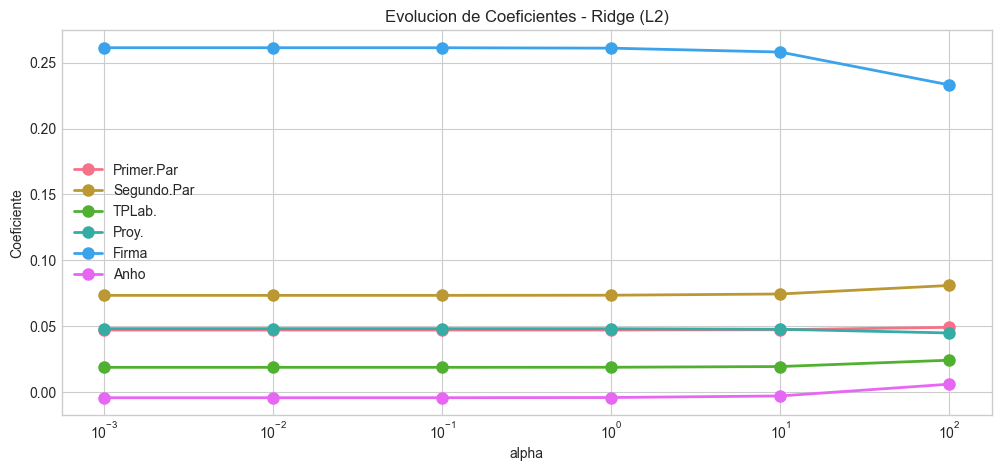

In [3]:
# =============================================================================
# 2.1 RIDGE (L2)
# =============================================================================
print("\n" + "="*80)
print("2.1 RIDGE REGRESSION (L2)")
print("="*80)

print("\nEcuacion: J(w) = MSE + alpha * sum(w_i^2)")
print("Efecto: Reduce coeficientes sin eliminarlos")

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_results = []
ridge_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    y_pred_binary = (y_pred > 0.5).astype(int)
    
    score = accuracy_score(y_test, y_pred_binary)
    ridge_results.append({
        'alpha': alpha,
        'accuracy': score,
        'coef_sum': np.sum(np.abs(ridge.coef_))
    })
    ridge_coefs.append(ridge.coef_)
    print(f"  alpha={alpha:6.3f} -> Accuracy: {score:.4f} | Suma|coef|: {np.sum(np.abs(ridge.coef_)):.3f}")

df_ridge = pd.DataFrame(ridge_results)
best_ridge_alpha = df_ridge.loc[df_ridge['accuracy'].idxmax(), 'alpha']
print(f"\n  Mejor alpha: {best_ridge_alpha}")

# Visualizacion: Evolucion de coeficientes
plt.figure(figsize=(12, 5))
ridge_coefs = np.array(ridge_coefs)
for i, var in enumerate(variables_existentes):
    plt.plot(alphas, ridge_coefs[:, i], 'o-', label=var, linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coeficiente')
plt.title('Evolucion de Coeficientes - Ridge (L2)')
plt.legend()
plt.grid(True)
plt.show()


2.2 LASSO REGRESSION (L1)

Ecuacion: J(w) = MSE + alpha * sum(|w_i|)
Efecto: Puede eliminar features (coeficientes = 0)
  alpha= 0.001 -> Accuracy: 0.9162 | Features seleccionadas: 5
  alpha= 0.010 -> Accuracy: 0.9162 | Features seleccionadas: 5
  alpha= 0.100 -> Accuracy: 0.8866 | Features seleccionadas: 2
  alpha= 1.000 -> Accuracy: 0.6824 | Features seleccionadas: 0
  alpha=10.000 -> Accuracy: 0.6824 | Features seleccionadas: 0
  alpha=100.000 -> Accuracy: 0.6824 | Features seleccionadas: 0

  Mejor alpha: 0.001


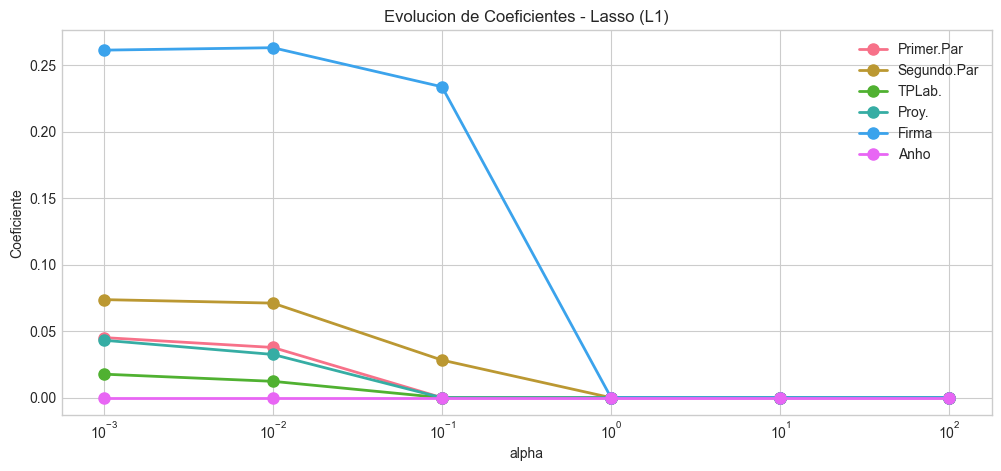

In [4]:
# =============================================================================
# 2.2 LASSO (L1)
# =============================================================================
print("\n" + "="*80)
print("2.2 LASSO REGRESSION (L1)")
print("="*80)

print("\nEcuacion: J(w) = MSE + alpha * sum(|w_i|)")
print("Efecto: Puede eliminar features (coeficientes = 0)")

lasso_results = []
lasso_coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    y_pred_binary = (y_pred > 0.5).astype(int)
    
    score = accuracy_score(y_test, y_pred_binary)
    n_features_selected = np.sum(np.abs(lasso.coef_) > 1e-6)
    
    lasso_results.append({
        'alpha': alpha,
        'accuracy': score,
        'features_selected': n_features_selected
    })
    lasso_coefs.append(lasso.coef_)
    print(f"  alpha={alpha:6.3f} -> Accuracy: {score:.4f} | Features seleccionadas: {n_features_selected}")

df_lasso = pd.DataFrame(lasso_results)
best_lasso_alpha = df_lasso.loc[df_lasso['accuracy'].idxmax(), 'alpha']
print(f"\n  Mejor alpha: {best_lasso_alpha}")

# Visualizacion: Evolucion de coeficientes
plt.figure(figsize=(12, 5))
lasso_coefs = np.array(lasso_coefs)
for i, var in enumerate(variables_existentes):
    plt.plot(alphas, lasso_coefs[:, i], 'o-', label=var, linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coeficiente')
plt.title('Evolucion de Coeficientes - Lasso (L1)')
plt.legend()
plt.grid(True)
plt.show()


2.3 ELASTIC NET (L1 + L2)

Ecuacion: J(w) = MSE + alpha*rho*sum(|w_i|) + (alpha*(1-rho)/2)*sum(w_i^2)
Efecto: Combina seleccion de features (L1) y agrupamiento (L2)
  alpha=0.01, rho=0.2 -> Accuracy: 0.9162
  alpha=0.01, rho=0.5 -> Accuracy: 0.9162
  alpha=0.01, rho=0.8 -> Accuracy: 0.9162
  alpha=0.10, rho=0.2 -> Accuracy: 0.9110
  alpha=0.10, rho=0.5 -> Accuracy: 0.9075
  alpha=0.10, rho=0.8 -> Accuracy: 0.9040
  alpha=1.00, rho=0.2 -> Accuracy: 0.6911
  alpha=1.00, rho=0.5 -> Accuracy: 0.6824
  alpha=1.00, rho=0.8 -> Accuracy: 0.6824
  alpha=10.00, rho=0.2 -> Accuracy: 0.6824
  alpha=10.00, rho=0.5 -> Accuracy: 0.6824
  alpha=10.00, rho=0.8 -> Accuracy: 0.6824

  Mejor combinacion: alpha=0.01, rho=0.2
     Accuracy: 0.9162


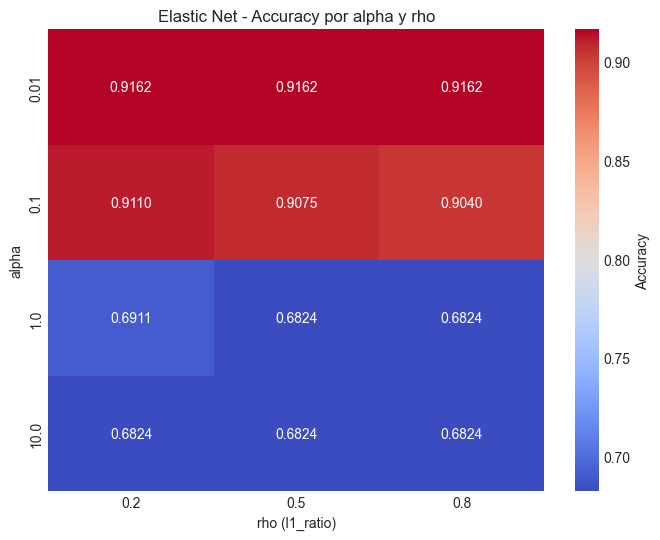

In [5]:
# =============================================================================
# 2.3 ELASTIC NET (L1 + L2)
# =============================================================================
print("\n" + "="*80)
print("2.3 ELASTIC NET (L1 + L2)")
print("="*80)

print("\nEcuacion: J(w) = MSE + alpha*rho*sum(|w_i|) + (alpha*(1-rho)/2)*sum(w_i^2)")
print("Efecto: Combina seleccion de features (L1) y agrupamiento (L2)")

alphas_elastic = [0.01, 0.1, 1, 10]
l1_ratios = [0.2, 0.5, 0.8]

elastic_results = []
for alpha in alphas_elastic:
    for l1_ratio in l1_ratios:
        elastic = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
        elastic.fit(X_train_scaled, y_train)
        y_pred = elastic.predict(X_test_scaled)
        y_pred_binary = (y_pred > 0.5).astype(int)
        
        score = accuracy_score(y_test, y_pred_binary)
        elastic_results.append({
            'alpha': alpha,
            'l1_ratio': l1_ratio,
            'accuracy': score
        })
        print(f"  alpha={alpha:.2f}, rho={l1_ratio:.1f} -> Accuracy: {score:.4f}")

df_elastic = pd.DataFrame(elastic_results)
best_elastic = df_elastic.loc[df_elastic['accuracy'].idxmax()]
print(f"\n  Mejor combinacion: alpha={best_elastic['alpha']:.2f}, rho={best_elastic['l1_ratio']:.1f}")
print(f"     Accuracy: {best_elastic['accuracy']:.4f}")

# Heatmap de resultados
pivot_table = df_elastic.pivot(index='alpha', columns='l1_ratio', values='accuracy')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt='.4f', cbar_kws={'label': 'Accuracy'})
plt.title('Elastic Net - Accuracy por alpha y rho')
plt.xlabel('rho (l1_ratio)')
plt.ylabel('alpha')
plt.show()

In [8]:
X_train_scaled

array([[-1.41600528, -1.14653613, -1.60664528, -0.81064348, -1.02932174,
        -1.03509834],
       [ 1.41115138,  0.72118789, -0.12715417, -0.81064348,  1.05391479,
         0.96609178],
       [ 0.40796676, -0.02590172, -1.2367725 , -0.81064348, -1.02932174,
        -1.03509834],
       ...,
       [ 1.68474719,  0.16087068,  0.24271861,  1.23358791,  0.74528715,
         0.96609178],
       [-0.04802625, -0.39944652, -0.12715417, -0.81064348, -1.02932174,
        -1.03509834],
       [ 0.86395977,  0.72118789,  0.61259139, -0.81064348,  0.93817942,
        -1.03509834]])


2.3 ELASTIC NET (L1 + L2)

Ecuacion: J(w) = BNC + alpha*rho*sum(|w_i|) + (alpha*(1-rho)/2)*sum(w_i^2)
Efecto: Combina seleccion de features (L1) y agrupamiento (L2)
  alpha=0.01, rho=0.2 -> Accuracy: 0.9284
  alpha=0.01, rho=0.5 -> Accuracy: 0.9284
  alpha=0.01, rho=0.8 -> Accuracy: 0.9284
  alpha=0.10, rho=0.2 -> Accuracy: 0.9284
  alpha=0.10, rho=0.5 -> Accuracy: 0.9284
  alpha=0.10, rho=0.8 -> Accuracy: 0.9284
  alpha=1.00, rho=0.2 -> Accuracy: 0.9250
  alpha=1.00, rho=0.5 -> Accuracy: 0.9250
  alpha=1.00, rho=0.8 -> Accuracy: 0.9267
  alpha=10.00, rho=0.2 -> Accuracy: 0.9180
  alpha=10.00, rho=0.5 -> Accuracy: 0.9215
  alpha=10.00, rho=0.8 -> Accuracy: 0.9284

  Mejor combinacion: alpha=0.01, rho=0.2
     Accuracy: 0.9284


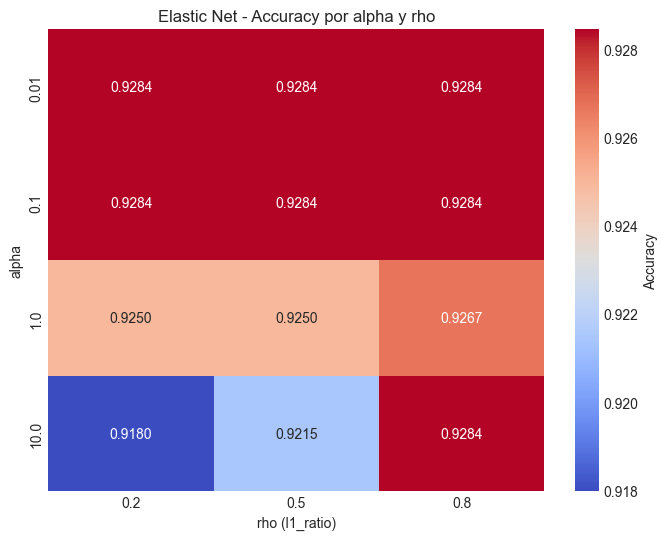

In [10]:
# =============================================================================
# 2.3 ELASTIC NET (L1 + L2)
# =============================================================================
print("\n" + "="*80)
print("2.3 ELASTIC NET (L1 + L2)")
print("="*80)

print("\nEcuacion: J(w) = BNC + alpha*rho*sum(|w_i|) + (alpha*(1-rho)/2)*sum(w_i^2)")
print("Efecto: Combina seleccion de features (L1) y agrupamiento (L2)")

alphas_elastic = [0.01, 0.1, 1, 10]
l1_ratios = [0.2, 0.5, 0.8]

elastic_results = []
for alpha in alphas_elastic:
    for l1_ratio in l1_ratios:
        elastic = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=l1_ratio, C=1/alpha, max_iter=10000)
        elastic.fit(X_train_scaled, y_train)
        y_pred = elastic.predict(X_test_scaled)
        y_pred_binary = (y_pred > 0.5).astype(int)
        
        score = accuracy_score(y_test, y_pred_binary)
        elastic_results.append({
            'alpha': alpha,
            'l1_ratio': l1_ratio,
            'accuracy': score,
            'coef': elastic.coef_   
        })
        print(f"  alpha={alpha:.2f}, rho={l1_ratio:.1f} -> Accuracy: {score:.4f}")

df_elastic = pd.DataFrame(elastic_results)
best_elastic = df_elastic.loc[df_elastic['accuracy'].idxmax()]
print(f"\n  Mejor combinacion: alpha={best_elastic['alpha']:.2f}, rho={best_elastic['l1_ratio']:.1f}")
print(f"     Accuracy: {best_elastic['accuracy']:.4f}")

# Heatmap de resultados
pivot_table = df_elastic.pivot(index='alpha', columns='l1_ratio', values='accuracy')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt='.4f', cbar_kws={'label': 'Accuracy'})
plt.title('Elastic Net - Accuracy por alpha y rho')
plt.xlabel('rho (l1_ratio)')
plt.ylabel('alpha')
plt.show()

In [ ]:
#Primer.Par', 'Segundo.Par', 'TPLab.', 'Proy.', 'Firma', 'Anho

In [13]:
df_elastic.coef.values

array([array([[0.35955911, 0.30468655, 0.5960741 , 0.79902963, 3.12183627,
               0.06641465]])                                              ,
       array([[0.3594935 , 0.30448021, 0.59599723, 0.79924251, 3.12240744,
               0.06620665]])                                              ,
       array([[0.35948092, 0.30420803, 0.59590533, 0.79940932, 3.1234382 ,
               0.06609432]])                                              ,
       array([[0.36009607, 0.31036931, 0.59602919, 0.79130207, 3.09574615,
               0.07094802]])                                              ,
       array([[0.35945636, 0.3080052 , 0.59509283, 0.7937358 , 3.10407828,
               0.06869432]])                                              ,
       array([[0.3589031 , 0.30576469, 0.59425797, 0.79561781, 3.11174941,
               0.06683188]])                                              ,
       array([[0.36342319, 0.35760385, 0.59338149, 0.73025328, 2.88113484,
               0.10

### PAUSA PRACTICA 1: REGULARIZACION

TAREAS:
1. Cambiar los valores de alpha y observar como afectan los coeficientes
2. Identificar que variables se eliminan con Lasso (coeficientes = 0)
3. Comparar la exactitud de los tres metodos

PREGUNTAS PARA REFLEXIONAR:
- Que pasa con los coeficientes cuando alpha aumenta?
- Cual metodo da mejor accuracy en test?
- Que caracteristicas se eliminan con Lasso?


EJERCICIO PRACTICO 1: EXPLORAR REGULARIZACION


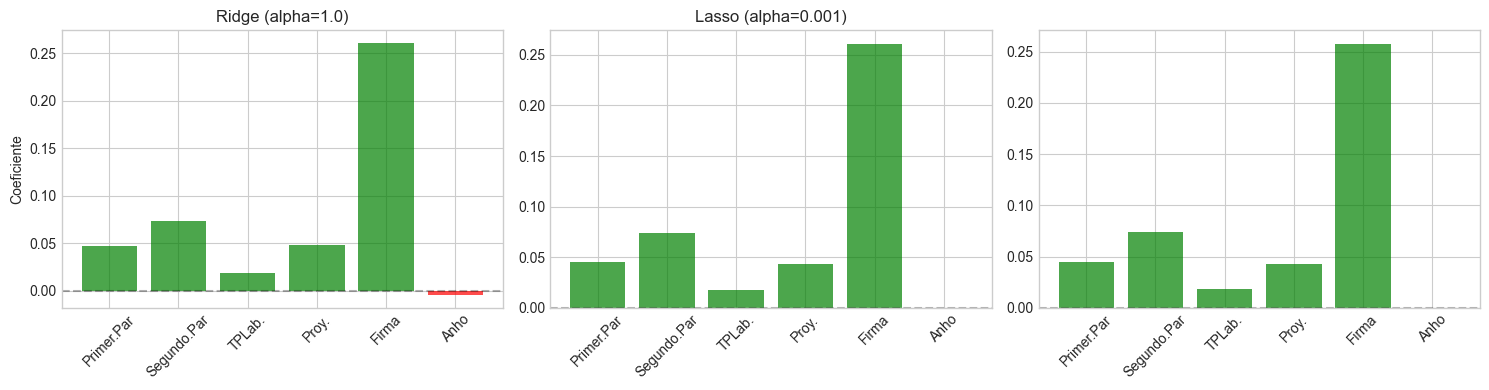


Comparacion de Coeficientes:
   Variable   Ridge   Lasso  Elastic Net
 Primer.Par  0.0470  0.0452       0.0449
Segundo.Par  0.0734  0.0737       0.0743
     TPLab.  0.0187  0.0177       0.0179
      Proy.  0.0480  0.0432       0.0427
      Firma  0.2611  0.2613       0.2580
       Anho -0.0043 -0.0000       0.0000


In [14]:
# =============================================================================
# EJERCICIO PRACTICO 1: EXPLORAR REGULARIZACION
# =============================================================================
print("\n" + "="*80)
print("EJERCICIO PRACTICO 1: EXPLORAR REGULARIZACION")
print("="*80)

# Comparacion visual de los tres metodos
best_ridge = Ridge(alpha=best_ridge_alpha)
best_ridge.fit(X_train_scaled, y_train)

best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)

best_elastic = ElasticNet(alpha=best_elastic['alpha'], l1_ratio=best_elastic['l1_ratio'], max_iter=10000)
best_elastic.fit(X_train_scaled, y_train)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
colors = ['green' if c > 0 else 'red' for c in best_ridge.coef_]
plt.bar(variables_existentes, best_ridge.coef_, color=colors, alpha=0.7)
plt.title(f'Ridge (alpha={best_ridge_alpha})')
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.ylabel('Coeficiente')

plt.subplot(1, 3, 2)
colors = ['green' if c > 0 else 'red' for c in best_lasso.coef_]
plt.bar(variables_existentes, best_lasso.coef_, color=colors, alpha=0.7)
plt.title(f'Lasso (alpha={best_lasso_alpha})')
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.subplot(1, 3, 3)
colors = ['green' if c > 0 else 'red' for c in best_elastic.coef_]
plt.bar(variables_existentes, best_elastic.coef_, color=colors, alpha=0.7)
#plt.title(f'Elastic Net (alpha={best_elastic["alpha"]:.2f}, rho={best_elastic["l1_ratio"]:.1f})')
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nComparacion de Coeficientes:")
comparison = pd.DataFrame({
    'Variable': variables_existentes,
    'Ridge': best_ridge.coef_,
    'Lasso': best_lasso.coef_,
    'Elastic Net': best_elastic.coef_
})
print(comparison.to_string(index=False))

## 3. Grid Search

Grid Search es una tecnica para encontrar los mejores hiperparametros de un modelo probando todas las combinaciones posibles de un conjunto de valores especificados.


3.1 GRID SEARCH - RIDGE
Buscando en 7 valores de alpha
Fitting 5 folds for each of 7 candidates, totalling 35 fits

  Mejores parametros: {'C': 0.1}
  Mejor score (CV): 0.9033


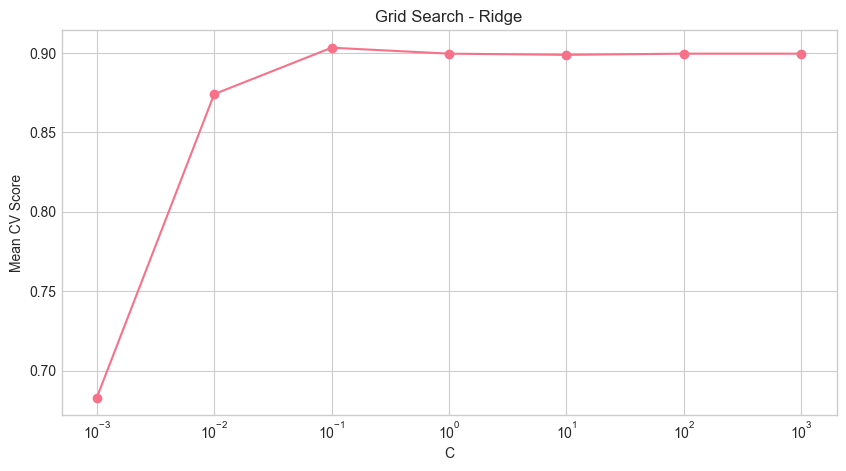

In [19]:
# =============================================================================
# 3.1 GRID SEARCH PARA RIDGE
# =============================================================================
print("\n" + "="*80)
print("3.1 GRID SEARCH - RIDGE")
print("="*80)

param_grid_ridge = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

print(f"Buscando en {len(param_grid_ridge['C'])} valores de alpha")
grid_ridge = GridSearchCV(
    LogisticRegression(penalty='l1', solver='saga', max_iter=10000),
    param_grid_ridge,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_ridge.fit(X_train_scaled, y_train)

print(f"\n  Mejores parametros: {grid_ridge.best_params_}")
print(f"  Mejor score (CV): {grid_ridge.best_score_:.4f}")
#print(f"  Test score: {grid_ridge.score(X_test_scaled, y_test):.4f}")

# Visualizacion de resultados
results_ridge = pd.DataFrame(grid_ridge.cv_results_)
plt.figure(figsize=(10, 5))
plt.plot(results_ridge['param_C'], results_ridge['mean_test_score'], 'o-')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV Score')
plt.title('Grid Search - Ridge')
plt.grid(True)
plt.show()

In [ ]:
# =============================================================================
# 3.2 GRID SEARCH PARA LASSO
# =============================================================================
print("\n" + "="*80)
print("3.2 GRID SEARCH - LASSO")
print("="*80)

param_grid_lasso = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1, 2, 5]
}

print(f"Buscando en {len(param_grid_lasso['alpha'])} valores de alpha")

grid_lasso = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid_lasso,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_lasso.fit(X_train_scaled, y_train)

print(f"\n  Mejores parametros: {grid_lasso.best_params_}")
print(f"  Mejor score (CV): {grid_lasso.best_score_:.4f}")
print(f"  Test score: {grid_lasso.score(X_test_scaled, y_test):.4f}")

# Visualizacion
results_lasso = pd.DataFrame(grid_lasso.cv_results_)
plt.figure(figsize=(10, 5))
plt.plot(results_lasso['param_alpha'], results_lasso['mean_test_score'], 'o-')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Mean CV Score')
plt.title('Grid Search - Lasso')
plt.grid(True)
plt.show()

In [ ]:
# =============================================================================
# 3.3 GRID SEARCH PARA ELASTIC NET
# =============================================================================
print("\n" + "="*80)
print("3.3 GRID SEARCH - ELASTIC NET")
print("="*80)

param_grid_elastic = {
    'alpha': [0.01, 0.05, 0.1, 0.5, 1],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

n_combinations = len(param_grid_elastic['alpha']) * len(param_grid_elastic['l1_ratio'])
print(f"Buscando en {n_combinations} combinaciones")

grid_elastic = GridSearchCV(
    ElasticNet(max_iter=10000),
    param_grid_elastic,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_elastic.fit(X_train_scaled, y_train)

print(f"\n  Mejores parametros: {grid_elastic.best_params_}")
print(f"  Mejor score (CV): {grid_elastic.best_score_:.4f}")
print(f"  Test score: {grid_elastic.score(X_test_scaled, y_test):.4f}")

# Visualizacion: Heatmap de resultados
results_elastic = pd.DataFrame(grid_elastic.cv_results_)
pivot_elastic = results_elastic.pivot_table(
    index='param_alpha', 
    columns='param_l1_ratio', 
    values='mean_test_score'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_elastic, annot=True, cmap='coolwarm', fmt='.4f', cbar_kws={'label': 'Mean CV Score'})
plt.title('Grid Search - Elastic Net')
plt.xlabel('rho (l1_ratio)')
plt.ylabel('alpha')
plt.show()

### PAUSA PRACTICA 2: GRID SEARCH

TAREAS:
1. Modificar los rangos de los parametros en Grid Search
2. Probar GridSearchCV con diferentes numeros de folds (cv)
3. Comparar los resultados con los modelos sin optimizar

PREGUNTAS PARA REFLEXIONAR:
- Que combinacion da mejor accuracy?
- Cuanto tiempo tarda la busqueda?
- Que ventaja tiene Random Search sobre Grid Search?

In [ ]:
# =============================================================================
# EJERCICIO PRACTICO 2: EXPLORAR GRID SEARCH
# =============================================================================
print("\n" + "="*80)
print("EJERCICIO PRACTICO 2: EXPLORAR GRID SEARCH")
print("="*80)

# Comparar diferentes configuraciones de Grid Search
param_grids = {
    'Fino': {'alpha': np.linspace(0.01, 1, 10)},
    'Grueso': {'alpha': [0.01, 0.1, 1, 10]},
    'Log': {'alpha': np.logspace(-3, 2, 10)}
}

for name, params in param_grids.items():
    print(f"\nGrid {name}: {len(params['alpha'])} valores")
    grid = GridSearchCV(Ridge(), params, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    print(f"   Mejor alpha: {grid.best_params_['alpha']:.4f}")
    print(f"   Best CV: {grid.best_score_:.4f}")
    print(f"   Test: {grid.score(X_test_scaled, y_test):.4f}")

## 4. SVM - Support Vector Machines

**Idea Principal:** Encontrar el hiperplano que separe las clases con el margen maximo.

In [ ]:
# =============================================================================
# 4.1 SVM LINEAL
# =============================================================================
print("\n" + "="*80)
print("4.1 SVM LINEAL")
print("="*80)

print("\nHiperplano: w*x + b = 0")
print("Parametro C: Controla el trade-off margen vs error")

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
svm_linear_results = []

for C in C_values:
    svm = SVC(kernel='linear', C=C, random_state=42)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    
    score = accuracy_score(y_test, y_pred)
    svm_linear_results.append({
        'C': C,
        'accuracy': score
    })
    print(f"  C={C:6.3f} -> Accuracy: {score:.4f}")

df_svm_linear = pd.DataFrame(svm_linear_results)
best_C_linear = df_svm_linear.loc[df_svm_linear['accuracy'].idxmax(), 'C']
print(f"\n  Mejor C: {best_C_linear}")

# Visualizacion
plt.figure(figsize=(10, 5))
plt.plot(df_svm_linear['C'], df_svm_linear['accuracy'], 'o-')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('SVM Lineal - Accuracy vs C')
plt.grid(True)
plt.show()

In [ ]:
# =============================================================================
# 4.2 SVM RBF (GAUSSIANO)
# =============================================================================
print("\n" + "="*80)
print("4.2 SVM RBF (GAUSSIANO)")
print("="*80)

print("\nKernel: K(x_i, x_j) = exp(-gamma * ||x_i - x_j||^2)")
print("gamma: Controla el alcance del kernel")
print("   - gamma grande -> decision local")
print("   - gamma pequeno -> decision global")

C_values = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

svm_rbf_results = []
for C in C_values:
    for gamma in gamma_values:
        svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
        svm.fit(X_train_scaled, y_train)
        y_pred = svm.predict(X_test_scaled)
        
        score = accuracy_score(y_test, y_pred)
        svm_rbf_results.append({
            'C': C,
            'gamma': gamma,
            'accuracy': score
        })
        print(f"  C={C:4.0f}, gamma={gamma:.3f} -> Accuracy: {score:.4f}")

df_svm_rbf = pd.DataFrame(svm_rbf_results)
best_svm = df_svm_rbf.loc[df_svm_rbf['accuracy'].idxmax()]
print(f"\n  Mejor combinacion: C={best_svm['C']:.0f}, gamma={best_svm['gamma']:.3f}")
print(f"     Accuracy: {best_svm['accuracy']:.4f}")

# Visualizacion: Heatmap de resultados
pivot_svm = df_svm_rbf.pivot(index='C', columns='gamma', values='accuracy')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_svm, annot=True, cmap='coolwarm', fmt='.4f', cbar_kws={'label': 'Accuracy'})
plt.title('SVM RBF - Accuracy por C y gamma')
plt.xlabel('gamma')
plt.ylabel('C')
plt.show()

In [ ]:
# =============================================================================
# 4.3 SVM CON GRID SEARCH
# =============================================================================
print("\n" + "="*80)
print("4.3 SVM CON GRID SEARCH")
print("="*80)

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

n_combinations = len(param_grid_svm['C']) * len(param_grid_svm['gamma'])
print(f"Buscando en {n_combinations} combinaciones")

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_svm.fit(X_train_scaled, y_train)

print(f"\n  Mejores parametros: {grid_svm.best_params_}")
print(f"  Mejor score (CV): {grid_svm.best_score_:.4f}")
print(f"  Test score: {grid_svm.score(X_test_scaled, y_test):.4f}")

# Visualizacion: Heatmap de Grid Search
results_svm = pd.DataFrame(grid_svm.cv_results_)
pivot_svm_grid = results_svm.pivot_table(
    index='param_C', 
    columns='param_gamma', 
    values='mean_test_score'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_svm_grid, annot=True, cmap='coolwarm', fmt='.4f', cbar_kws={'label': 'Mean CV Score'})
plt.title('Grid Search - SVM RBF')
plt.xlabel('gamma')
plt.ylabel('C')
plt.show()

### PAUSA PRACTICA 3: SVM BASICO

TAREAS:
1. Comparar SVM lineal vs SVM RBF
2. Visualizar el margen de decision (usando 2 features)
3. Identificar los vectores soporte

PREGUNTAS PARA REFLEXIONAR:
- Cual kernel da mejor accuracy?
- Que pasa si cambias C y gamma?
- Como se comparan con Regresion Logistica?

In [ ]:
# =============================================================================
# EJERCICIO PRACTICO 3: VISUALIZAR SVM
# =============================================================================
print("\n" + "="*80)
print("EJERCICIO PRACTICO 3: VISUALIZAR SVM")
print("="*80)

# Seleccionar 2 features para visualizacion
features_2d = ['Primer.Par', 'Segundo.Par']
X_train_2d = X_train[features_2d]
X_test_2d = X_test[features_2d]

# Escalar
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Entrenar diferentes SVM
svms = {
    'SVM Lineal (C=1)': SVC(kernel='linear', C=1, random_state=42),
    'SVM RBF (C=1, gamma=0.1)': SVC(kernel='rbf', C=1, gamma=0.1, random_state=42),
    'SVM RBF (C=10, gamma=0.01)': SVC(kernel='rbf', C=10, gamma=0.01, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, svm) in zip(axes, svms.items()):
    svm.fit(X_train_2d_scaled, y_train)
    
    # Crear malla
    x_min, x_max = X_train_2d_scaled[:, 0].min() - 0.5, X_train_2d_scaled[:, 0].max() + 0.5
    y_min, y_max = X_train_2d_scaled[:, 1].min() - 0.5, X_train_2d_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Graficar
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train_2d_scaled[y_train==0, 0], X_train_2d_scaled[y_train==0, 1], 
               c='red', label='Reprobados', alpha=0.6, s=30)
    ax.scatter(X_train_2d_scaled[y_train==1, 0], X_train_2d_scaled[y_train==1, 1], 
               c='blue', label='Aprobados', alpha=0.6, s=30)
    
    # Vectores soporte
    if hasattr(svm, 'support_vectors_'):
        ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
                   s=200, facecolors='none', edgecolors='green', linewidths=2,
                   label=f'SV ({len(svm.support_vectors_)})')
    
    ax.set_xlabel('Primer Parcial (normalizado)')
    ax.set_ylabel('Segundo Parcial (normalizado)')
    ax.set_title(f'{name}\nAccuracy: {svm.score(X_test_2d_scaled, y_test):.3f}')
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Comparacion de Modelos

In [ ]:
# =============================================================================
# 5. COMPARACION DE TODOS LOS MODELOS
# =============================================================================
print("\n" + "="*80)
print("5. COMPARACION DE MODELOS")
print("="*80)

# Definir todos los modelos optimizados
models = {
    'Regresion Logistica': LogisticRegression(random_state=42, max_iter=1000),
    'Ridge (L2)': Ridge(alpha=grid_ridge.best_params_['alpha']),
    'Lasso (L1)': Lasso(alpha=grid_lasso.best_params_['alpha'], max_iter=10000),
    'Elastic Net': ElasticNet(alpha=grid_elastic.best_params_['alpha'],
                              l1_ratio=grid_elastic.best_params_['l1_ratio'], max_iter=10000),
    'SVM Lineal': SVC(kernel='linear', C=best_C_linear, random_state=42),
    'SVM RBF (Grid)': SVC(kernel='rbf', C=grid_svm.best_params_['C'],
                          gamma=grid_svm.best_params_['gamma'], random_state=42),
}

results = []

for name, model in models.items():
    # Entrenar
    if name in ['Ridge (L2)', 'Lasso (L1)', 'Elastic Net']:
        model.fit(X_train_scaled, y_train)
        y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
        y_pred_train = (model.predict(X_train_scaled) > 0.5).astype(int)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_train = model.predict(X_train_scaled)
    
    # Metricas
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred)
    
    results.append({
        'Modelo': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Overfitting': train_acc - test_acc,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0)
    })

df_results = pd.DataFrame(results)
print("\nCOMPARACION DE MODELOS:")
print(df_results.to_string(index=False))

# Grafico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de barras - Accuracy
ax1 = axes[0]
x = np.arange(len(df_results))
width = 0.35
ax1.bar(x - width/2, df_results['Train Acc'], width, label='Train', color='blue', alpha=0.7)
ax1.bar(x + width/2, df_results['Test Acc'], width, label='Test', color='green', alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(df_results['Modelo'], rotation=45, ha='right')
ax1.set_ylabel('Accuracy')
ax1.set_title('Comparacion de Modelos - Train vs Test')
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

# Grafico de barras - Overfitting
ax2 = axes[1]
colors = ['red' if o > 0.05 else 'green' for o in df_results['Overfitting']]
ax2.barh(df_results['Modelo'], df_results['Overfitting'], color=colors, alpha=0.7)
ax2.set_xlabel('Overfitting (Train - Test)')
ax2.set_title('Sobrecaje (Overfitting)')
ax2.axvline(x=0.05, color='red', linestyle='--', alpha=0.5, label='Umbral 5%')
ax2.legend()

plt.tight_layout()
plt.show()

### PAUSA PRACTICA 4: SVM OPTIMIZADO

TAREAS:
1. Usar GridSearchCV con diferentes kernels (linear, rbf, poly, sigmoid)
2. Probar diferentes rangos de C y gamma
3. Analizar los vectores soporte

PREGUNTAS PARA REFLEXIONAR:
- Mejoro la prediccion de aprobacion?
- Que combinacion C-gamma es mejor?
- Se puede usar SVM para regresion (SVR)?

In [ ]:
# =============================================================================
# EJERCICIO PRACTICO 4: EXPLORAR KERNELS
# =============================================================================
print("\n" + "="*80)
print("EJERCICIO PRACTICO 4: EXPLORAR KERNELS")
print("="*80)

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_results = []

for kernel in kernels:
    try:
        svm = SVC(kernel=kernel, random_state=42)
        scores = cross_val_score(svm, X_train_scaled, y_train, cv=5)
        kernel_results.append({
            'kernel': kernel,
            'mean_score': scores.mean(),
            'std_score': scores.std()
        })
        print(f"  {kernel:8s} -> CV Score: {scores.mean():.4f} +- {scores.std():.4f}")
    except Exception as e:
        print(f"  {kernel:8s} -> Error: {e}")

df_kernels = pd.DataFrame(kernel_results)
best_kernel = df_kernels.loc[df_kernels['mean_score'].idxmax(), 'kernel']
print(f"\n  Mejor kernel: {best_kernel}")

# Grid Search con multiples kernels
print("\nGrid Search con multiples kernels...")
param_grid_multi = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

grid_multi = GridSearchCV(SVC(random_state=42), param_grid_multi, cv=3, scoring='accuracy', n_jobs=-1)
grid_multi.fit(X_train_scaled, y_train)

print(f"\n  Mejores parametros: {grid_multi.best_params_}")
print(f"  Best CV: {grid_multi.best_score_:.4f}")
print(f"  Test: {grid_multi.score(X_test_scaled, y_test):.4f}")

## 6. Conclusiones

In [ ]:
# =============================================================================
# 6. CONCLUSIONES
# =============================================================================
print("\n" + "="*80)
print("6. CONCLUSIONES")
print("="*80)

print("""
PRINCIPALES APRENDIZAJES:

1. REGULARIZACION:
   - L2 (Ridge): Reduce coeficientes sin eliminarlos
   - L1 (Lasso): Puede eliminar features (seleccion de caracteristicas)
   - Elastic Net: Combina lo mejor de ambos
   - alpha controla la fuerza de la regularizacion

2. GRID SEARCH:
   - Permite encontrar los mejores hiperparametros
   - Usa validacion cruzada para evitar overfitting
   - Es computacionalmente costoso pero efectivo
   - Se puede usar con cualquier modelo

3. SVM:
   - Encuentra el hiperplano con margen maximo
   - Kernel trick permite trabajar en altas dimensiones
   - RBF es el kernel mas versatil
   - C controla el trade-off margen vs error
   - gamma controla el alcance del kernel RBF

4. COMPARACION:
   - SVM RBF supera a modelos lineales en este problema
   - La regularizacion mejora la generalizacion
   - Grid Search es esencial para optimizar SVM

PROXIMOS PASOS:
   - Probar SVM con features del estudio CNMAC
   - Implementar SVR para regresion
   - Comparar con MLP (Redes Neuronales)
   - Analizar vectores soporte
""")

# Resumen final
print("\nRESUMEN FINAL:")
print("-" * 50)
best_model = df_results.loc[df_results['Test Acc'].idxmax()]
print(f"Mejor modelo: {best_model['Modelo']}")
print(f"   Test Accuracy: {best_model['Test Acc']:.4f}")
print(f"   Train Accuracy: {best_model['Train Acc']:.4f}")
print(f"   Overfitting: {best_model['Overfitting']:.4f}")

print("\n" + "="*80)
print("PRACTICA COMPLETADA EXITOSAMENTE")
print("="*80)